In [1]:
import pandas as pd
import numpy as np

# Create dataset
data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Maths': [85, 90, np.nan, 70, 95, 88, 120, 76],   # 120 = outlier
    'Science': [78, 85, 88, np.nan, 92, 81, 79, 300], # 300 = outlier
    'English': [72, 80, 75, 70, np.nan, 78, 74, 73],
    'Gender': ['M', 'F', 'F', 'M', 'F', 'M', 'M', 'F']
}

df = pd.DataFrame(data)
print(df)

  Name  Maths  Science  English Gender
0    A   85.0     78.0     72.0      M
1    B   90.0     85.0     80.0      F
2    C    NaN     88.0     75.0      F
3    D   70.0      NaN     70.0      M
4    E   95.0     92.0      NaN      F
5    F   88.0     81.0     78.0      M
6    G  120.0     79.0     74.0      M
7    H   76.0    300.0     73.0      F


In [2]:
df=pd.DataFrame(data)

In [3]:
print(df)

  Name  Maths  Science  English Gender
0    A   85.0     78.0     72.0      M
1    B   90.0     85.0     80.0      F
2    C    NaN     88.0     75.0      F
3    D   70.0      NaN     70.0      M
4    E   95.0     92.0      NaN      F
5    F   88.0     81.0     78.0      M
6    G  120.0     79.0     74.0      M
7    H   76.0    300.0     73.0      F


In [4]:
df.isnull().sum()

Name       0
Maths      1
Science    1
English    1
Gender     0
dtype: int64

In [14]:
# Fill numeric with mean
df['Maths'].fillna(df['Maths'].mean())
df['Science'].fillna(df['Science'].mean())
df['English'].fillna(df['English'].mean())

0    72.000000
1    80.000000
2    75.000000
3    70.000000
4    74.571429
5    78.000000
6    74.000000
7    73.000000
Name: English, dtype: float64

In [16]:
df['Maths'].isna().sum()

np.int64(0)

In [17]:
df['Science'].isna().sum()

np.int64(0)

In [18]:
df['English'].isna().sum()

np.int64(0)

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

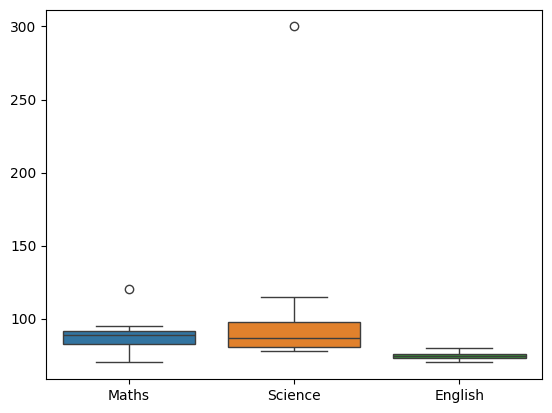

In [27]:
sns.boxplot(data=df[['Maths','Science','English']])
plt.show()

In [46]:
def remove_outliers(column):
    q1=column.quantile(0.25)
    q3 = column.quantile(0.75)
    IQR=q3-q1

    lower=q1-1.5*IQR
    upper=q3+1.5*IQR

    return np.where(column > upper, upper,np.where(column < lower, lower, column))

In [47]:
df['Maths'] = remove_outliers(df['Maths'])
df['Science'] = remove_outliers(df['Science'])
df['English'] = remove_outliers(df['English'])

In [48]:
print(df)

  Name       Maths     Science    English Gender
0    A   85.000000   78.000000  72.000000      M
1    B   90.000000   85.000000  80.000000      F
2    C   89.142857   88.000000  75.000000      F
3    D   70.000000  114.714286  70.000000      M
4    E   95.000000   92.000000  74.571429      F
5    F   88.000000   81.000000  78.000000      M
6    G  104.000000   79.000000  74.000000      M
7    H   76.000000  123.446429  73.000000      F


In [50]:
plt.barplot(data=df['Maths','Science','English'])

AttributeError: module 'matplotlib.pyplot' has no attribute 'barplot'